# Reproducing the paper figures from the released traces

This notebook reproduces paper figure derivable from the public
GitHub Copilot agentic coding trace release, using the
paper's styling/plotting code (`paper_figures.py` + `paper_style.py`).

**Prerequisites:** Download the trace shards from the
[GitHub release](https://github.com/Azure/AzurePublicDataset/releases/tag/ghcp-coding-agent-2026)
into the `downloaded_data/` folder, then `pip install -r requirements.txt`.
Run this notebook from this directory.

In [1]:
import os
import glob
import pandas as pd
from IPython.display import Image, display, Markdown

import trace_loader
import trace_metrics
import paper_style
import paper_figures as F
import make_figures as M


## 1. Verify the local data

The trace shards should already be in `downloaded_data/` (downloaded from the
[GitHub release](https://github.com/Azure/AzurePublicDataset/releases/tag/ghcp-coding-agent-2026)).
The following cell checks that the shards are present.

In [2]:
paths = trace_loader.shard_paths()
print(f"Found {len(paths)} shard file(s) in {trace_loader.DEFAULT_CACHE}")
assert len(paths) > 0, (
    "No shards found! Download the trace data from the GitHub release "
    "into downloaded_data/ first. See README.md for instructions."
)

import os
csv_dir = M.DATA
existing_csvs = [f for f in os.listdir(csv_dir) if f.endswith(".csv")] if os.path.isdir(csv_dir) else []
SKIP_AGGREGATE = len(existing_csvs) >= 20
if SKIP_AGGREGATE:
    print(f"Found {len(existing_csvs)} pre-built CSVs in {csv_dir} — will skip aggregation.")
else:
    print(f"Only {len(existing_csvs)} CSVs found — will rebuild from traces.")

Found 606 shard file(s) in /mnt/raid0/hqiu/AzurePublicDataset/analysis/GitHubCopilotCodingAgents/downloaded_data
Found 24 pre-built CSVs in /mnt/raid0/hqiu/AzurePublicDataset/analysis/GitHubCopilotCodingAgents/data — will skip aggregation.


## 2. Load the traces and describe the dataset scale

Flatten every session into tidy per-call / per-batch / per-turn tables, then
report the overall scale of the dataset before plotting anything.

In [3]:
if SKIP_AGGREGATE:
    print("Skipping trace loading (pre-built CSVs available).")
    frames = None
    summary = None
else:
    frames = trace_loader.load_dataframes()
    summary = trace_metrics.scale_summary(frames)

    labels = {
        "date_range": "Date range (UTC)",
        "n_days": "Days",
        "sessions": "Agentic sessions",
        "turns": "User turns",
        "llm_calls": "LLM calls",
        "tool_batches": "Tool batches",
        "tool_calls": "Individual tool calls",
        "distinct_models": "Distinct (user-facing) models",
        "prompt_tokens": "Prompt tokens (sum)",
        "completion_tokens": "Completion tokens (sum)",
        "cached_tokens": "Cached prompt tokens (sum)",
        "avg_turns_per_session": "Avg turns / session",
        "avg_llm_calls_per_turn": "Avg LLM calls / turn",
        "avg_tool_calls_per_turn": "Avg tool calls / turn",
    }

    def _fmt(v):
        return f"{v:,.0f}" if isinstance(v, float) and v == int(v) else (
            f"{v:,}" if isinstance(v, int) else str(v))

    overview = pd.DataFrame(
        [(labels[k], _fmt(summary[k])) for k in labels],
        columns=["Metric", "Value"],
    )
    display(Markdown("### Dataset scale overview"))
    display(overview.style.hide(axis="index"))

Skipping trace loading (pre-built CSVs available).


## 3. Aggregate the traces into the paper's intermediate tables

Re-derives every reproducible `data/*.csv` from the loaded traces, over the full
downloaded population.

In [4]:
if SKIP_AGGREGATE:
    print(f"Reusing {len(existing_csvs)} pre-built CSVs in {M.DATA}")
else:
    tables = trace_metrics.build_all(frames)
    trace_metrics.write_all(tables, out_dir=M.DATA)
    print(f"{len(tables)} tables written to {M.DATA}")

Reusing 24 pre-built CSVs in /mnt/raid0/hqiu/AzurePublicDataset/analysis/GitHubCopilotCodingAgents/data


## 4. Render the figures

We reuse the paper's plotting code unchanged. `paper_style.save_fig` normally
writes a PDF; here we wrap it to *also* drop a PNG next to each PDF so the
figures can be shown inline below.

In [5]:
PNG_DIR = os.path.join(M.OUT, "png")
os.makedirs(PNG_DIR, exist_ok=True)

_orig_save_fig = paper_style.save_fig

def _save_fig_with_png(fig, name, output_dir=None, pad_inches=0.0):
    path = _orig_save_fig(fig, name, output_dir=output_dir, pad_inches=pad_inches)
    try:
        fig.savefig(os.path.join(PNG_DIR, f"{name}.png"), format="png",
                    dpi=200, bbox_inches="tight", pad_inches=max(pad_inches, 0.02))
    except Exception as exc:  # fig may already be closed by _orig_save_fig
        print(f"  (png skipped for {name}: {exc})")
    return path

paper_style.save_fig = _save_fig_with_png

print("Group A (matplotlib defaults) ...")
M.group_a(M.OUT)
print("Group B (paper_style.setup_style) ...")
M.group_b(M.OUT)

paper_style.save_fig = _orig_save_fig
pdfs = sorted(glob.glob(os.path.join(M.OUT, "*.pdf")))
print(f"\nDone. {len(pdfs)} PDFs in {M.OUT} (PNG previews in {PNG_DIR}).")

Group A (matplotlib defaults) ...


Group B (paper_style.setup_style) ...


  Saved tool_time_nested_by_bucket.pdf



Done. 36 PDFs in /mnt/raid0/hqiu/AzurePublicDataset/analysis/GitHubCopilotCodingAgents/figures (PNG previews in /mnt/raid0/hqiu/AzurePublicDataset/analysis/GitHubCopilotCodingAgents/figures/png).


## 5. Show the reproduced figures inline

**cache_hit_rate_cdf**

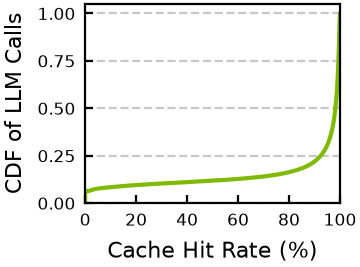

**cache_rate_by_call_position_half_col**

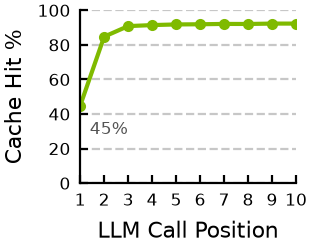

**cache_rate_vs_idle_boxplot**

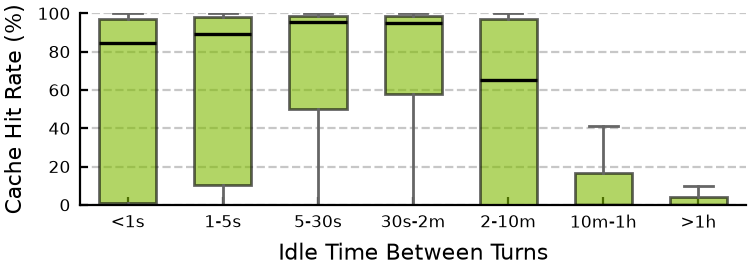

**compaction_severity**

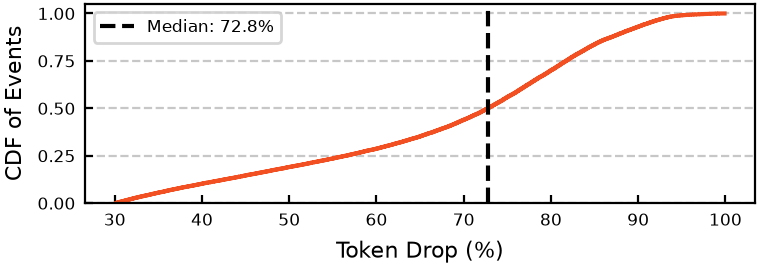

**compaction_severity_cache_hit_drop**

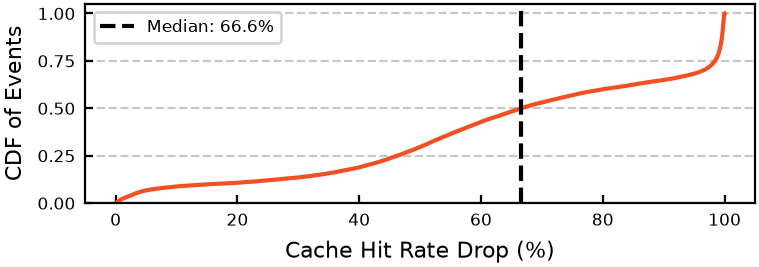

**compaction_token_bucket_delta_cdf**

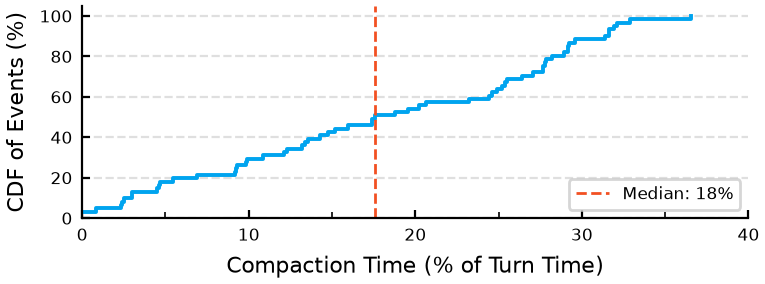

**error_signal_composition_by_depth**

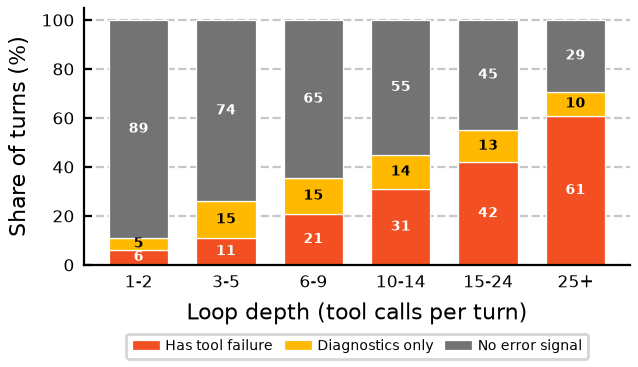

**llm_parallelism**

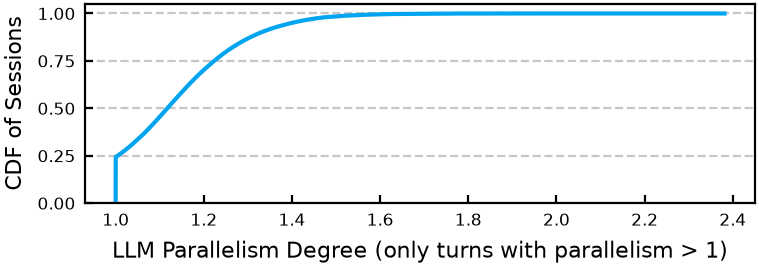

**llm_parallelism_all**

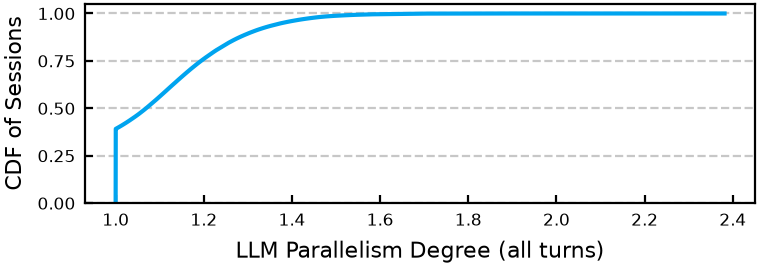

**model_distribution_anonymized**

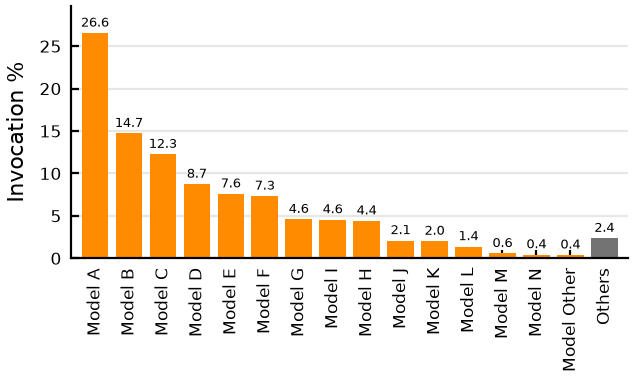

**model_share_trend**

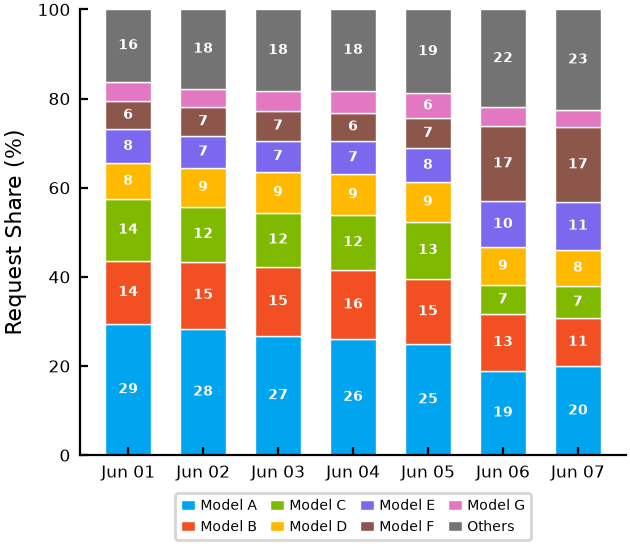

**normalized_trends**

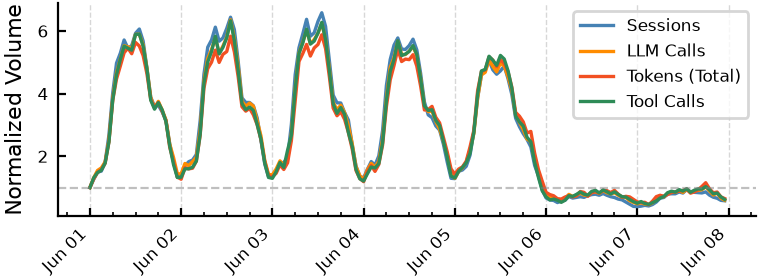

**per_session_calls_cdf**

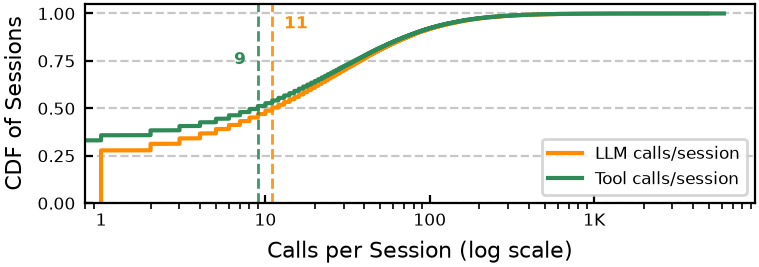

**per_tool_parallelism**

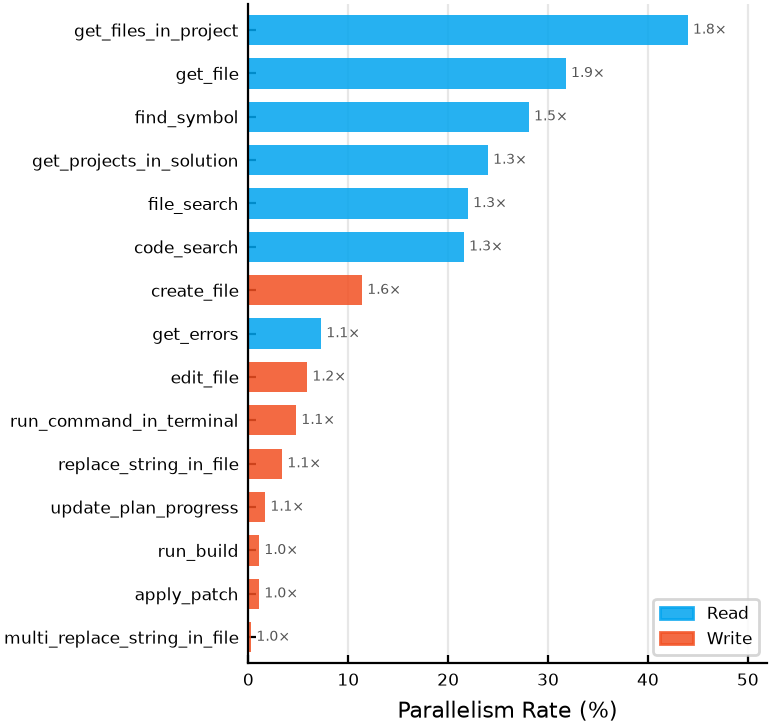

**per_turn_calls_cdf**

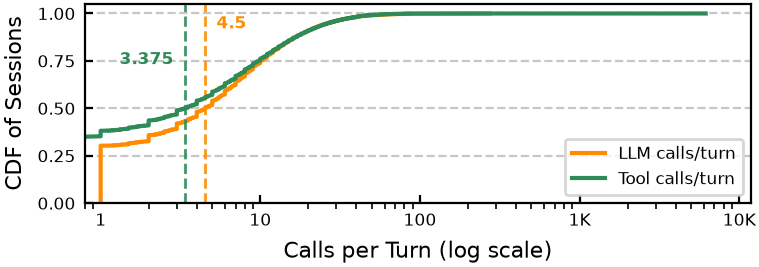

**per_turn_token_count_cdf**

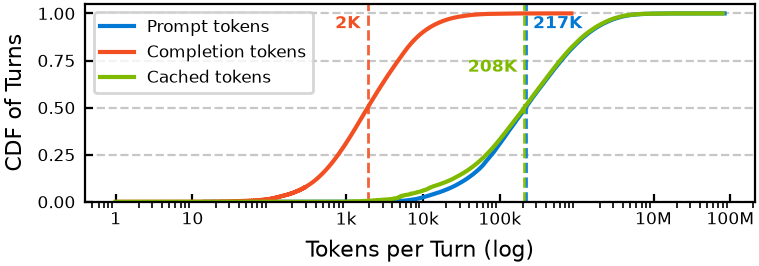

**session_avg_trends**

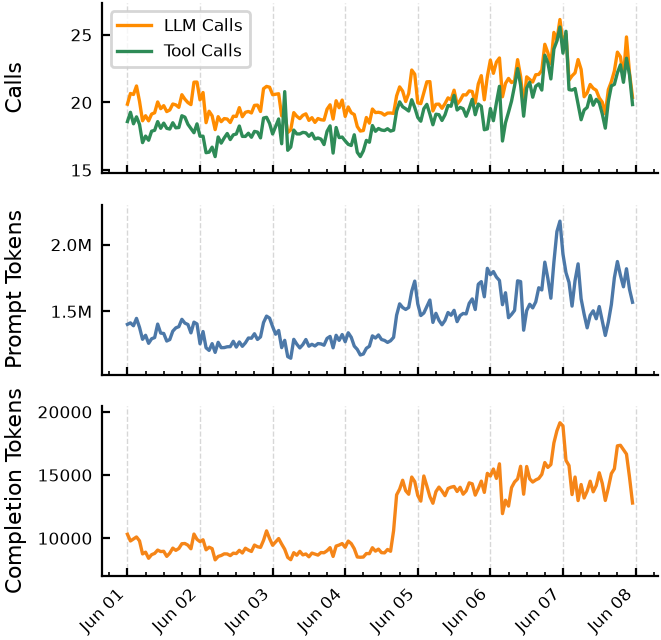

**session_duration_hist_cdf_logscale_vs**

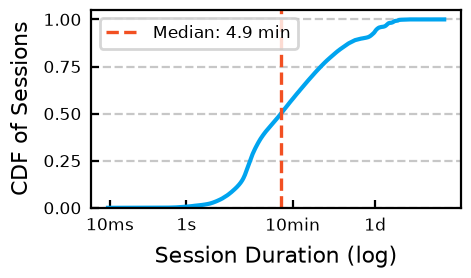

**session_turns_cdf**

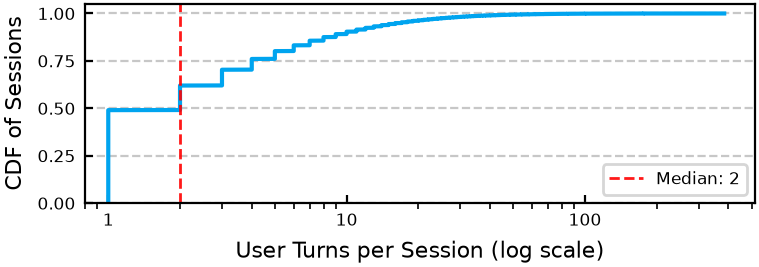

**time_breakdown_llm_tool_cdf_single_turn_vs**

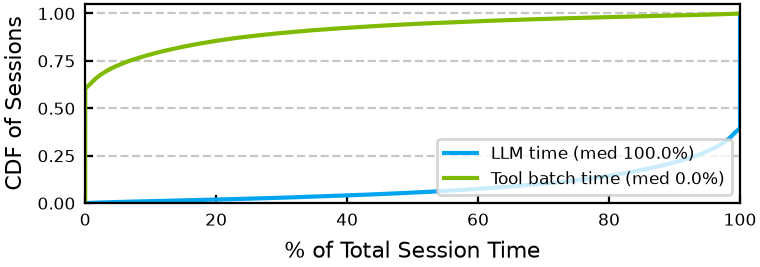

**time_breakdown_llm_tool_user_cdf_multi_turn_vs**

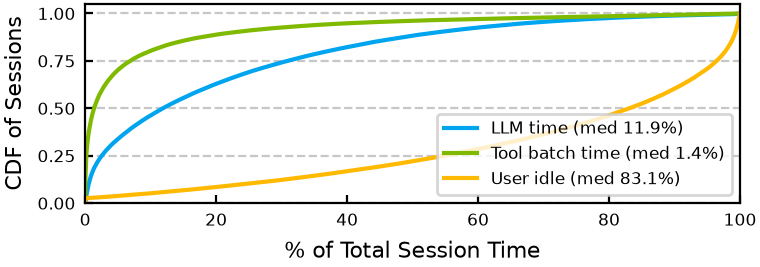

**time_breakdown_llm_tool_user_cdf_vs**

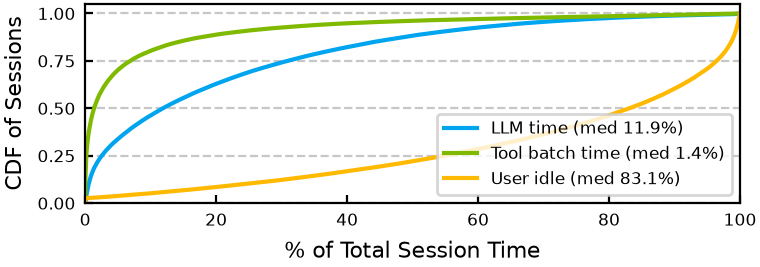

**token_count_cdf**

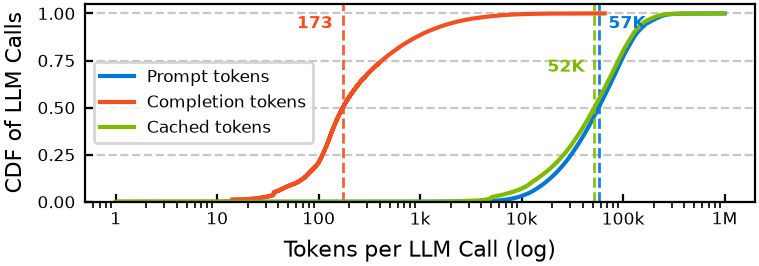

**token_type_breakdown**

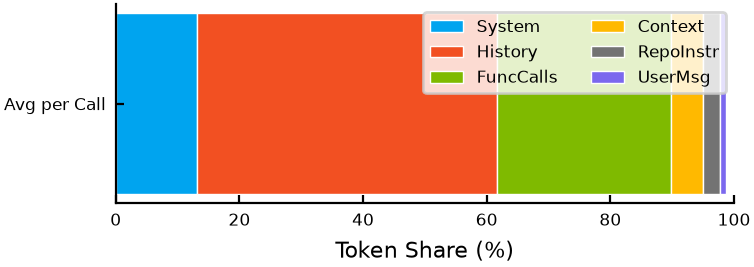

**tool_driven_idle_time_cdf**

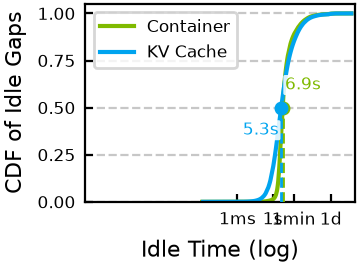

**tool_duration_by_status**

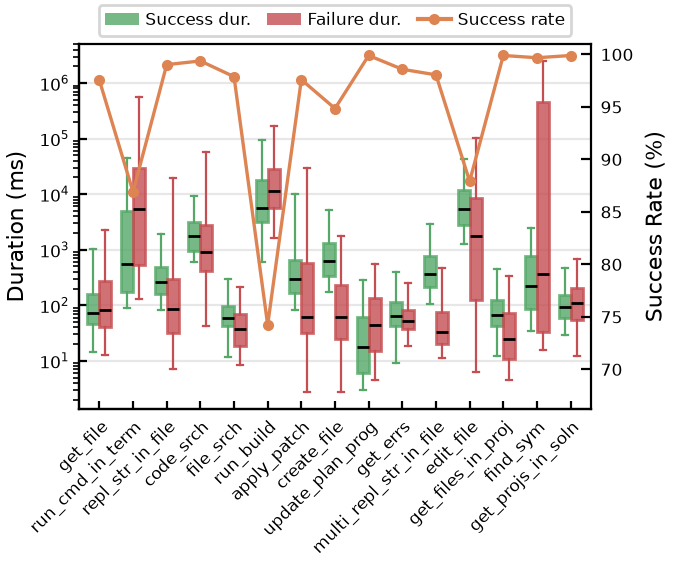

**tool_duration_cdf**

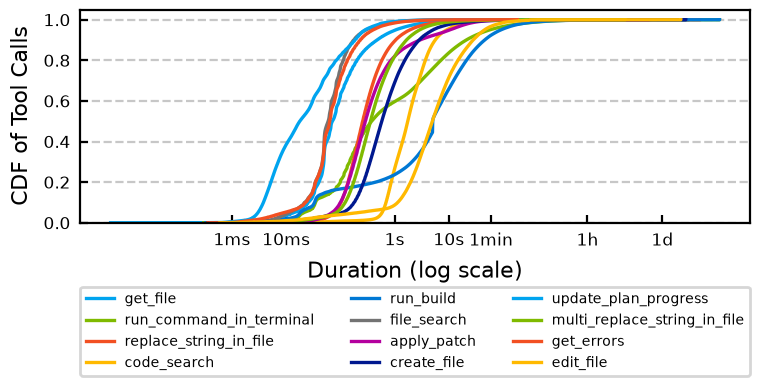

**tool_duration_cdf_total**

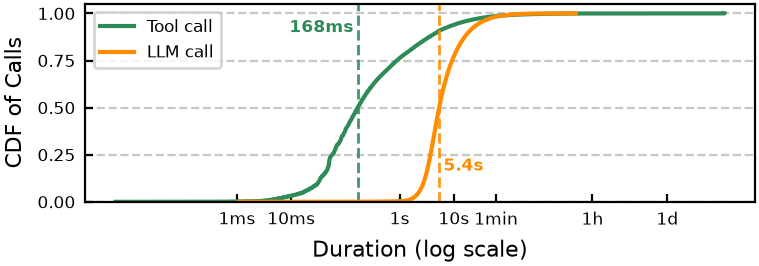

**tool_parallelism**

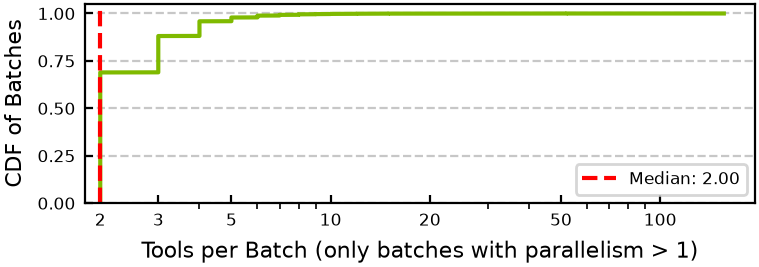

**tool_time_nested_by_bucket**

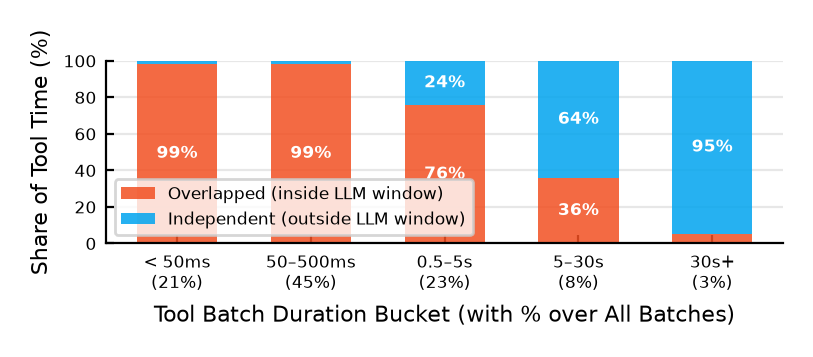

**tool_token_delta_by_status**

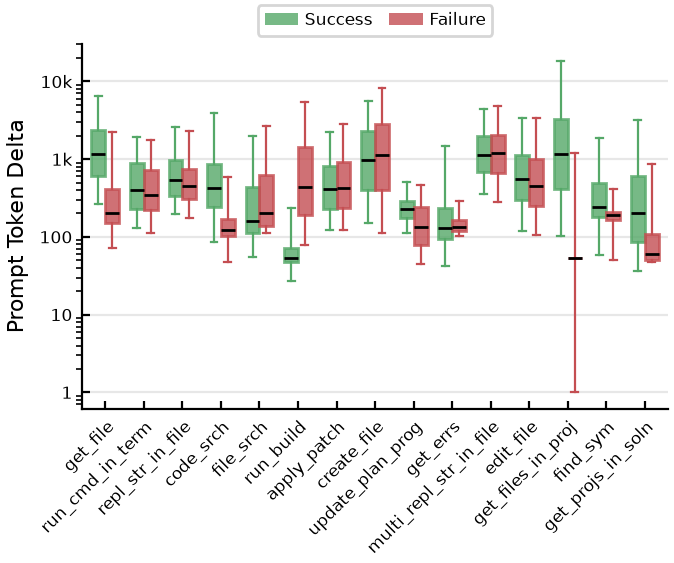

**tool_usage_bar**

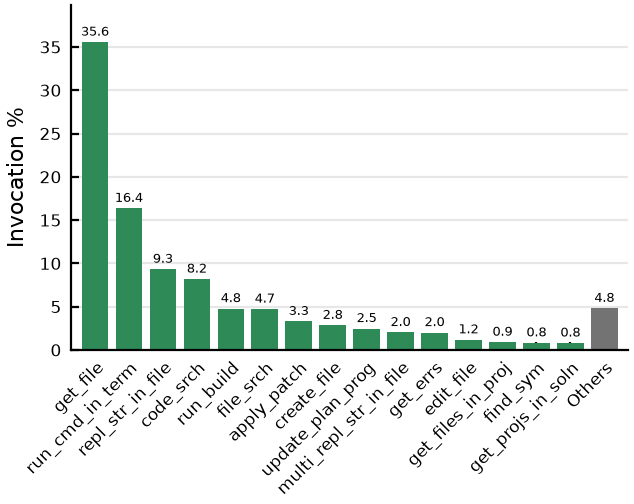

**turn_boundary_cache_rate**

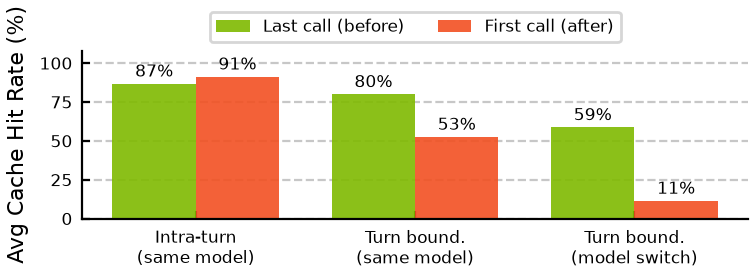

**turn_calls_weekday_weekend_bars**

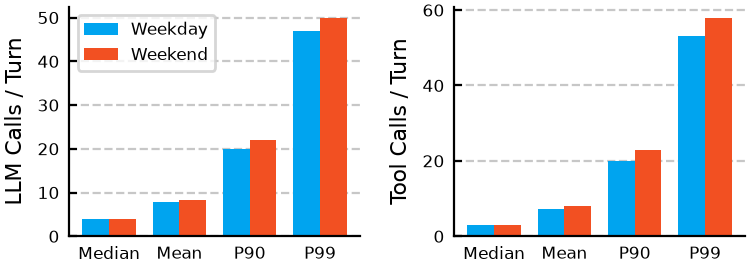

**turn_duration_hist_cdf_logscale_vs**

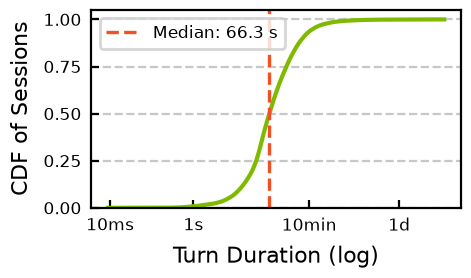

**user_idle_time_cdf**

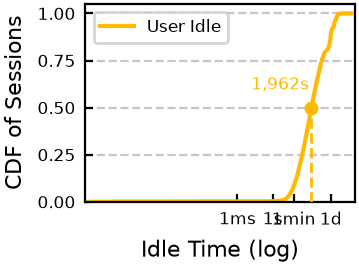

In [6]:
for png in sorted(glob.glob(os.path.join(PNG_DIR, "*.png"))):
    display(Markdown(f"**{os.path.splitext(os.path.basename(png))[0]}**"))
    display(Image(filename=png))